# Scene Analysis
Visualise scene cuts, subsegment cuts, the underlying FD signals that drove the segmentation, and per-subsegment motion metrics.

**Workflow**
1. Set `ANALYSIS_JSON` to the `.analysis.json` produced by `scene_selection.py`.
2. Run all cells top-to-bottom.

The file contains:
- `flow_decomposition` – per-frame [pan, tilt, zoom, camera_magnitude, roll, scene_activity, moving_object_ratio]
- `flow_stats` – per-frame [mean_magnitude, coherence, dominant_direction]
- `frame_metrics` – per-frame [sharpness, brightness, clipping]
- `scenes` – primary segments (Pelt l2 on fd signal), each with `subsegments` (Pelt l1) and `channel_metrics`

In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.signal import savgol_filter
from scipy.stats import spearmanr

# DJI_20250514105245_0135_D
# DJI_20250801134716_0192_D
# DJI_20250802144037_0199_D
# DJI_20250802150946_0204_D
# DJI_20250803144140_0220_D
# DJI_20250803143318_0215_D

# ── CONFIG ────────────────────────────────────────────────────────────────────
BASE_NAME = "DJI_20250514105245_0135_D"

PATH = "../local/videos/"
ANALYSIS_JSON = PATH + BASE_NAME + ".analysis.json"   # ← change me

# Smoothing params (must match what was used during analysis)
SAVGOL_WIN  = 11
SAVGOL_POLY = 2

FD_COLS     = ["pan", "tilt", "zoom", "camera_magnitude"]
CHANNELS    = ["pan", "tilt", "zoom"]          # channels with subsegment metrics
CHAN_COLORS = {"pan": "#4e79a7", "tilt": "#f28e2b", "zoom": "#59a14f"}
# ─────────────────────────────────────────────────────────────────────────────

with open(ANALYSIS_JSON) as f:
    data = json.load(f)

print(f"Video   : {data['video_path']}")
print(f"Duration: {data['duration']:.1f}s")
print(f"Scenes  : {data['num_scenes']}")
for s in data['scenes']:
    print(f"  Scene {s['scene_id']:2d}  {s['start_time']:.2f}s – {s['end_time']:.2f}s "
          f"({s['duration']:.1f}s)  quality={s['quality_score']:.3f}  "
          f"subsegments={len(s['subsegments'])}")

Video   : local/videos/DJI_20250514105245_0135_D.MP4
Duration: 120.0s
Scenes  : 6
  Scene  0  0.00s – 12.75s (12.8s)  quality=0.956  subsegments=1
  Scene  1  12.75s – 61.50s (48.8s)  quality=0.905  subsegments=6
  Scene  4  96.50s – 110.25s (13.8s)  quality=0.890  subsegments=4
  Scene  3  74.00s – 96.50s (22.5s)  quality=0.871  subsegments=3
  Scene  2  61.50s – 74.00s (12.5s)  quality=0.868  subsegments=2
  Scene  5  110.25s – 120.00s (9.8s)  quality=0.858  subsegments=3


In [17]:
# ── Build DataFrames ──────────────────────────────────────────────────────────

fd   = pd.DataFrame(data["flow_decomposition"])
fs   = pd.DataFrame(data["flow_stats"])
fm   = pd.DataFrame(data["frame_metrics"])

# Reproduce the smoothed + normalised signal used for segmentation
def preprocess(df, cols, win=SAVGOL_WIN, poly=SAVGOL_POLY):
    X = df[cols].values.astype(np.float64).copy()
    n = len(X)
    w = min(win, n if n % 2 == 1 else n - 1)
    w = max(w, poly + 1 if (poly + 1) % 2 == 1 else poly + 2)
    for i in range(X.shape[1]):
        if n >= w:
            X[:, i] = savgol_filter(X[:, i], window_length=w, polyorder=poly)
    for i in range(X.shape[1]):
        lo, hi = X[:, i].min(), X[:, i].max()
        if hi - lo > 1e-8:
            X[:, i] = (X[:, i] - lo) / (hi - lo)
    return pd.DataFrame(X, columns=cols, index=df.index)

fd_norm = preprocess(fd, FD_COLS)
fd_norm["timestamp"] = fd["timestamp"]

# Boundary lists
scene_cuts   = data.get("boundaries", [])
flow_cuts    = data.get("flow_boundaries", [])
emb_cuts     = data.get("emb_boundaries", [])

# Flat table of all subsegments across all scenes
subseg_rows = []
for s in data["scenes"]:
    for sub in s["subsegments"]:
        row = {
            "scene_id":      s["scene_id"],
            "subsegment_id": sub["subsegment_id"],
            "start_time":    sub["start_time"],
            "end_time":      sub["end_time"],
            "duration":      sub["duration"],
        }
        for ch in CHANNELS:
            for metric, val in sub["channel_metrics"][ch].items():
                row[f"{ch}_{metric}"] = val
        subseg_rows.append(row)
subs = pd.DataFrame(subseg_rows)

print(f"flow_decomposition : {len(fd)} rows")
print(f"flow_stats         : {len(fs)} rows")
print(f"frame_metrics      : {len(fm)} rows")
print(f"subsegments        : {len(subs)} rows")
subs.head()

flow_decomposition : 481 rows
flow_stats         : 481 rows
frame_metrics      : 120 rows
subsegments        : 19 rows


,scene_id,subsegment_id,start_time,end_time,duration,pan_mean_abs,pan_rms,pan_entry_vel,pan_exit_vel,pan_monotonicity,...,tilt_monotonicity,tilt_mean_abs_deriv,tilt_std_deriv,zoom_mean_abs,zoom_rms,zoom_entry_vel,zoom_exit_vel,zoom_monotonicity,zoom_mean_abs_deriv,zoom_std_deriv
0,0,0,0.50,12.5,12.00,0.000499,0.000740,-0.000105,-0.003552,-0.524750,...,-0.085758,0.000932,0.001308,0.000564,0.000943,0.000202,0.005454,0.609097,0.001098,0.001989
1,1,0,12.75,15.0,2.25,0.014194,0.014984,-0.020259,0.007989,0.900000,...,0.433333,0.009243,0.011372,0.017714,0.018628,0.023577,-0.004852,-0.950000,0.011060,0.011544
2,1,1,15.00,40.0,25.00,0.005830,0.007537,0.008713,-0.010750,-0.068119,...,0.165653,0.007428,0.010215,0.006498,0.008369,-0.009200,0.011747,0.058506,0.010450,0.014085
3,1,2,40.00,47.5,7.50,0.027024,0.027385,-0.007608,-0.001370,-0.020690,...,0.459844,0.005339,0.006290,0.031997,0.032573,0.015409,0.010152,0.358843,0.010075,0.012001
4,1,3,47.50,55.0,7.50,0.004324,0.006546,0.022241,0.019437,0.805562,...,0.325473,0.006139,0.007359,0.005972,0.009332,-0.028945,-0.021925,-0.913682,0.008130,0.011583


## 1 · Overview — scene & subsegment cuts on the FD signal

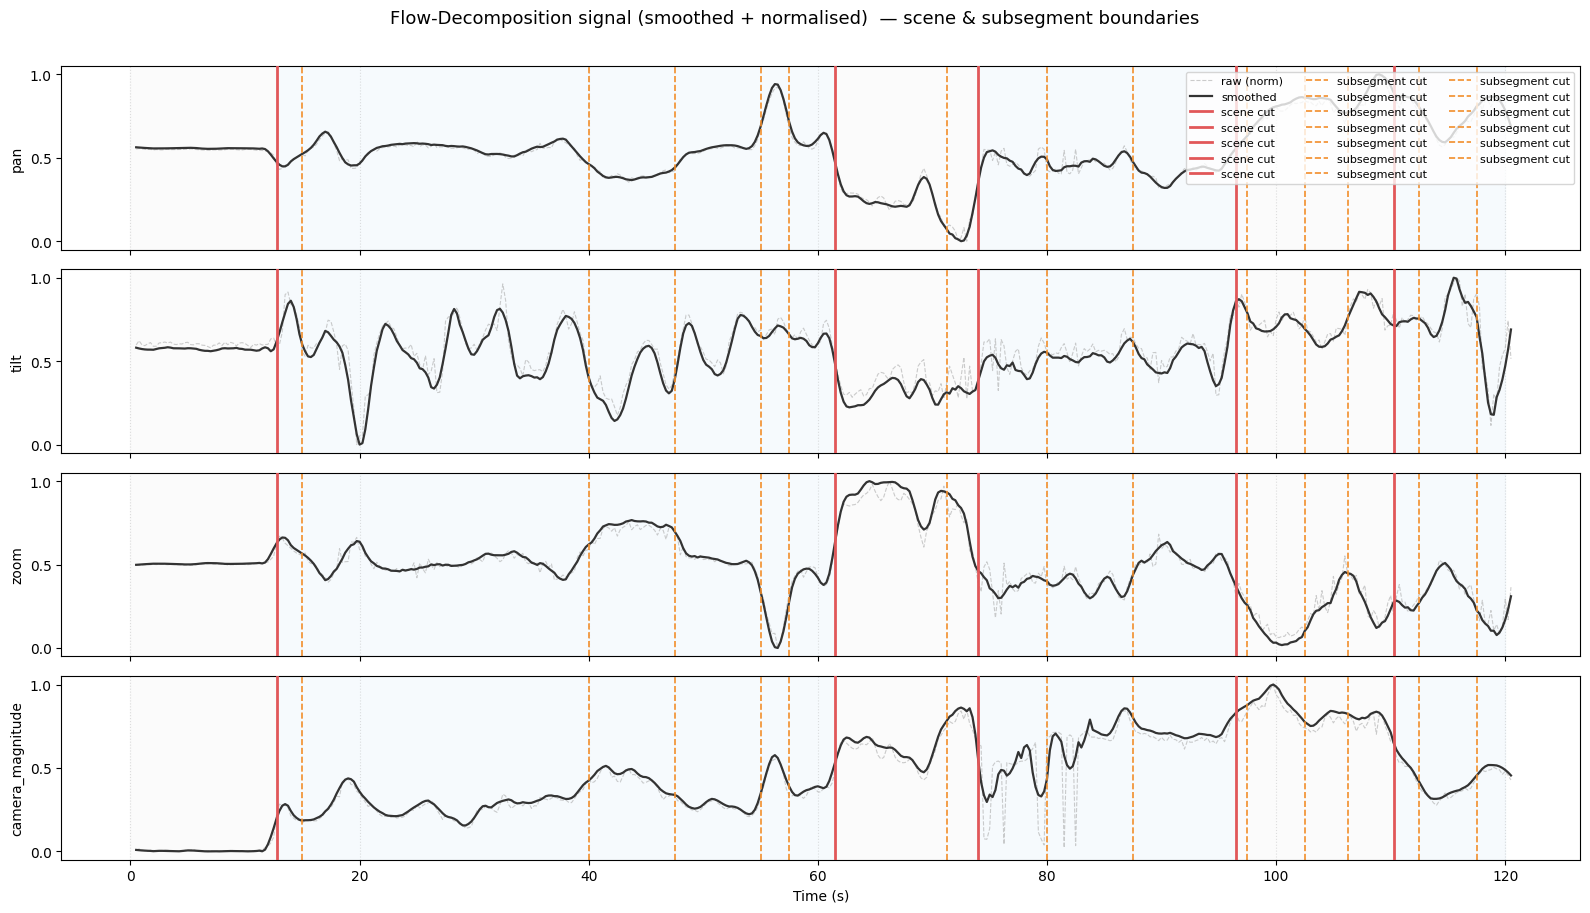

In [18]:
fig, axes = plt.subplots(len(FD_COLS), 1, figsize=(16, 9), sharex=True)
fig.suptitle("Flow-Decomposition signal (smoothed + normalised)  — scene & subsegment boundaries",
             fontsize=13, y=1.01)

# Background shading per scene
scene_bg = ["#f7f7f7", "#eaf3fb"]

for ax, col in zip(axes, FD_COLS):
    # Raw (lightly dashed) vs smoothed+normalised (solid)
    raw = fd[col].values.astype(float)
    raw_norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    ax.plot(fd["timestamp"], raw_norm,
            color="#aaa", lw=0.8, ls="--", alpha=0.6, label="raw (norm)")
    ax.plot(fd_norm["timestamp"], fd_norm[col],
            color="#333", lw=1.6, label="smoothed")

    # Scene background bands
    for i, s in enumerate(data["scenes"]):
        ax.axvspan(s["start_time"], s["end_time"],
                   color=scene_bg[i % 2], alpha=0.4, zorder=0)

    # Scene cuts (primary)
    for t in scene_cuts[1:-1]:
        ax.axvline(t, color="#e15759", lw=2.0, ls="-", zorder=3,
                   label="scene cut" if col == FD_COLS[0] else "")

    # Subsegment cuts (per scene)
    for s in data["scenes"]:
        for sub in s["subsegments"][1:]:   # skip first edge (= scene start)
            ax.axvline(sub["start_time"], color="#f28e2b",
                       lw=1.2, ls="--", zorder=2,
                       label="subsegment cut" if col == FD_COLS[0] else "")

    ax.set_ylabel(col, fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.grid(axis="x", ls=":", alpha=0.4)

axes[0].legend(loc="upper right", fontsize=8, ncol=3)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 2 · All three boundary sources compared

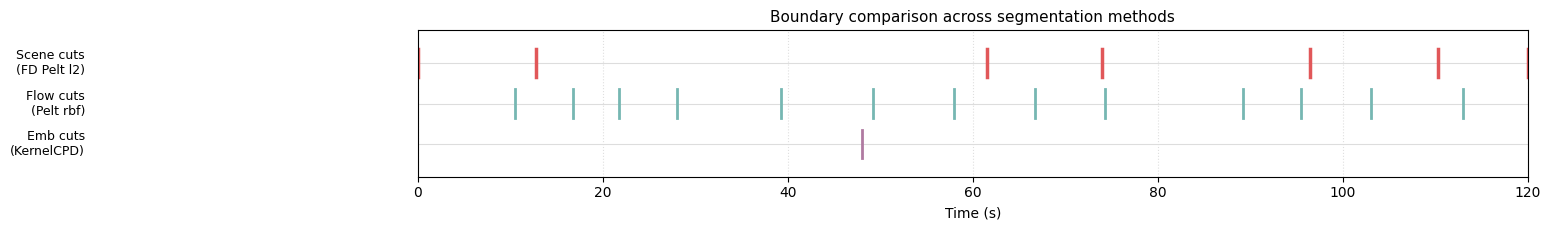

In [19]:
fig, ax = plt.subplots(figsize=(16, 2.4))
duration = data["duration"]

def draw_cuts(ax, cuts, y, color, label, lw=2):
    ax.axhline(y, color="#ddd", lw=0.8)
    for t in cuts:
        ax.plot([t, t], [y - 0.35, y + 0.35], color=color, lw=lw)
    ax.text(-0.3, y, label, ha="right", va="center", fontsize=9,
            transform=ax.get_yaxis_transform())

draw_cuts(ax, scene_cuts, 2, "#e15759", "Scene cuts\n(FD Pelt l2)", lw=2.5)
draw_cuts(ax, flow_cuts,  1, "#76b7b2", "Flow cuts\n(Pelt rbf)", lw=2)
draw_cuts(ax, emb_cuts,   0, "#b07aa1", "Emb cuts\n(KernelCPD)", lw=2)

ax.set_xlim(0, duration)
ax.set_ylim(-0.8, 2.8)
ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_title("Boundary comparison across segmentation methods", fontsize=11)
ax.grid(axis="x", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## 3 · Raw flow-decomposition channels (unsmoothed)

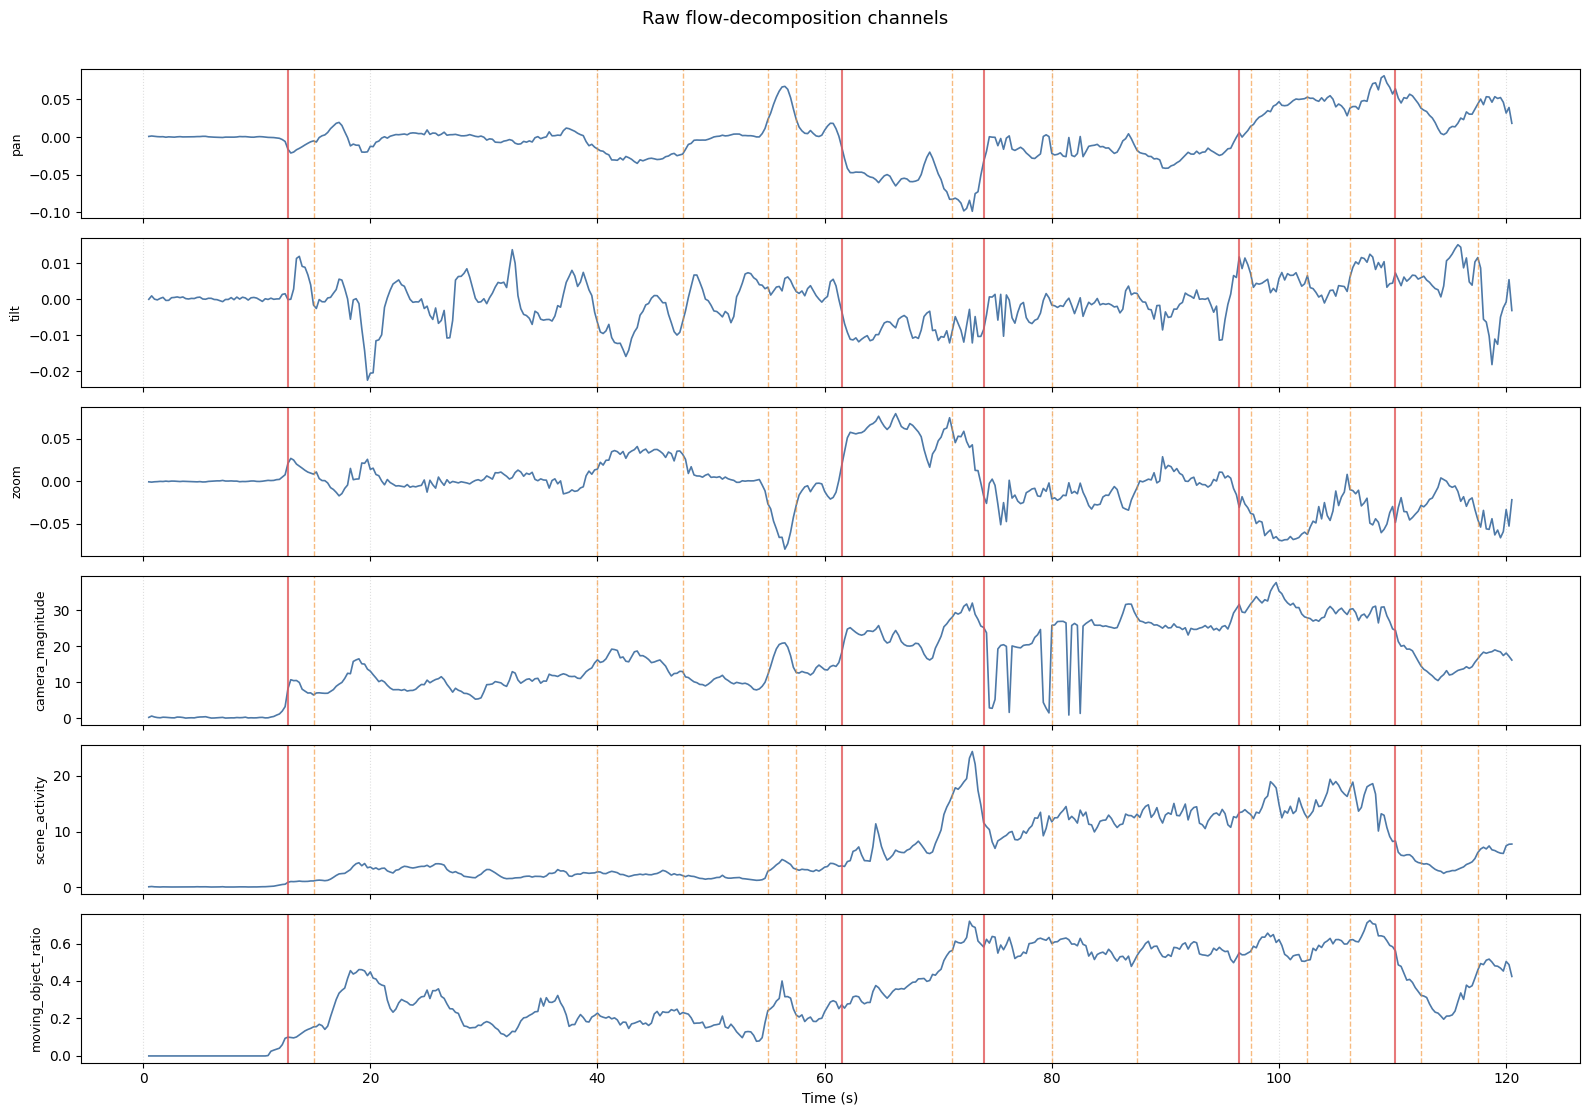

In [20]:
RAW_COLS = ["pan", "tilt", "zoom", "camera_magnitude", "scene_activity", "moving_object_ratio"]
fig, axes = plt.subplots(len(RAW_COLS), 1, figsize=(16, 11), sharex=True)
fig.suptitle("Raw flow-decomposition channels", fontsize=13, y=1.01)

for ax, col in zip(axes, RAW_COLS):
    ax.plot(fd["timestamp"], fd[col], lw=1.2, color="#4e79a7")
    for t in scene_cuts[1:-1]:
        ax.axvline(t, color="#e15759", lw=1.5, ls="-", alpha=0.8)
    for s in data["scenes"]:
        for sub in s["subsegments"][1:]:
            ax.axvline(sub["start_time"], color="#f28e2b", lw=1.0, ls="--", alpha=0.6)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(axis="x", ls=":", alpha=0.4)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 4 · Quality & flow-stats signals

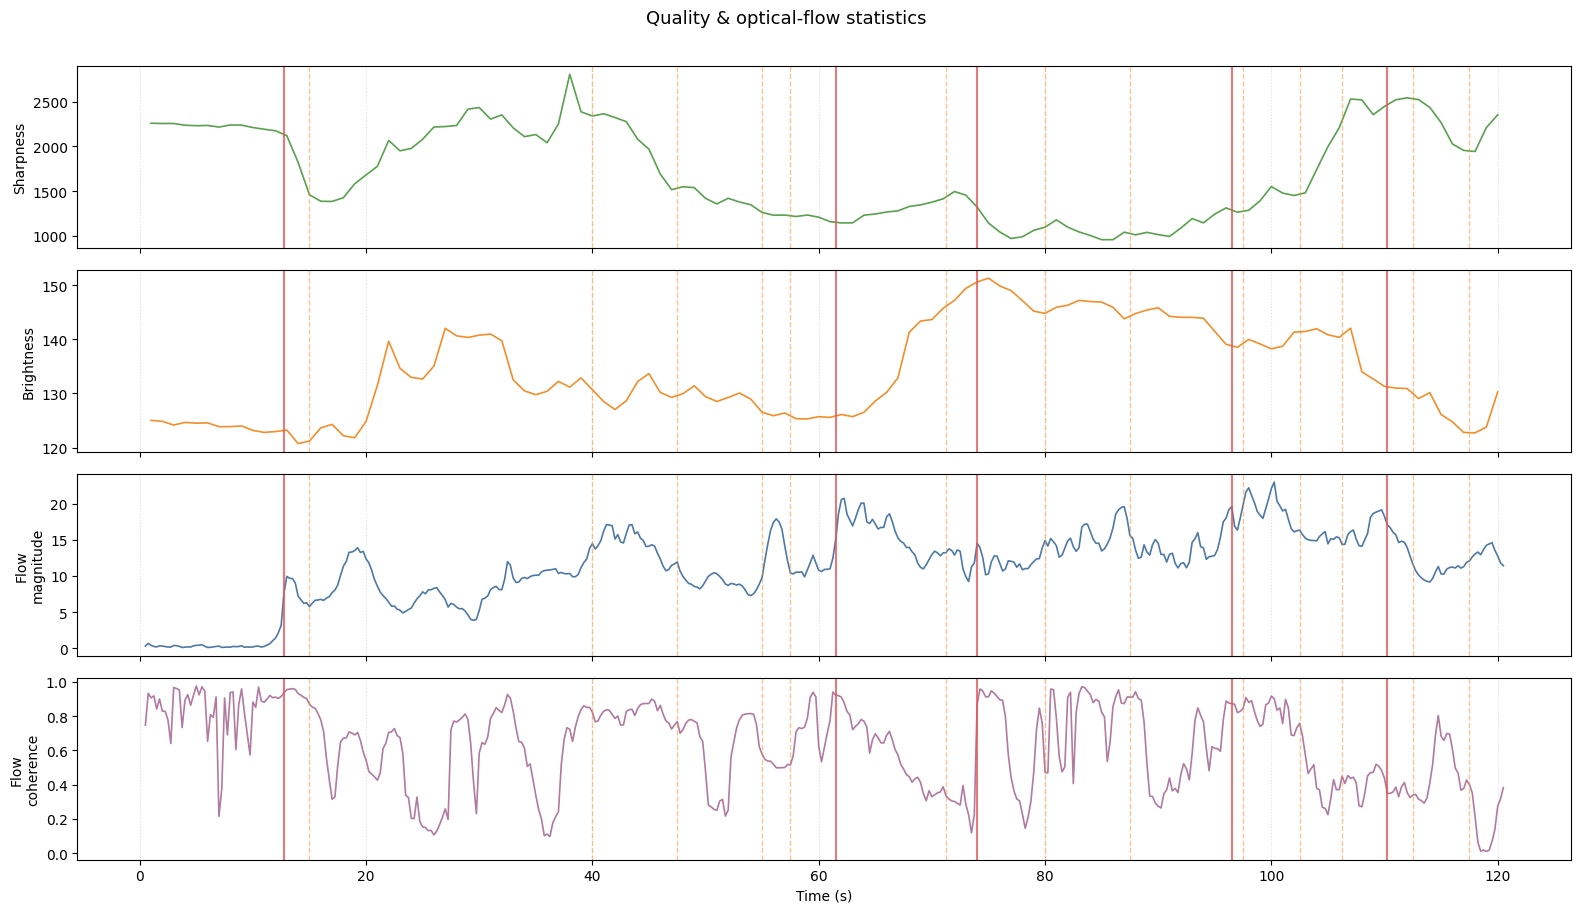

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(16, 9), sharex=True)
fig.suptitle("Quality & optical-flow statistics", fontsize=13, y=1.01)

def vlines(ax):
    for t in scene_cuts[1:-1]:
        ax.axvline(t, color="#e15759", lw=1.5, ls="-", alpha=0.8)
    for s in data["scenes"]:
        for sub in s["subsegments"][1:]:
            ax.axvline(sub["start_time"], color="#f28e2b", lw=1.0, ls="--", alpha=0.5)

axes[0].plot(fm["timestamp"], fm["sharpness"], color="#59a14f", lw=1.2)
axes[0].set_ylabel("Sharpness"); vlines(axes[0])

axes[1].plot(fm["timestamp"], fm["mean_brightness"], color="#f28e2b", lw=1.2)
axes[1].set_ylabel("Brightness"); vlines(axes[1])

axes[2].plot(fs["timestamp"], fs["mean_magnitude"], color="#4e79a7", lw=1.2)
axes[2].set_ylabel("Flow\nmagnitude"); vlines(axes[2])

axes[3].plot(fs["timestamp"], fs["coherence"], color="#b07aa1", lw=1.2)
axes[3].set_ylabel("Flow\ncoherence"); vlines(axes[3])

for ax in axes:
    ax.grid(axis="x", ls=":", alpha=0.4)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 5 · Per-scene detail: signal + subsegment metrics

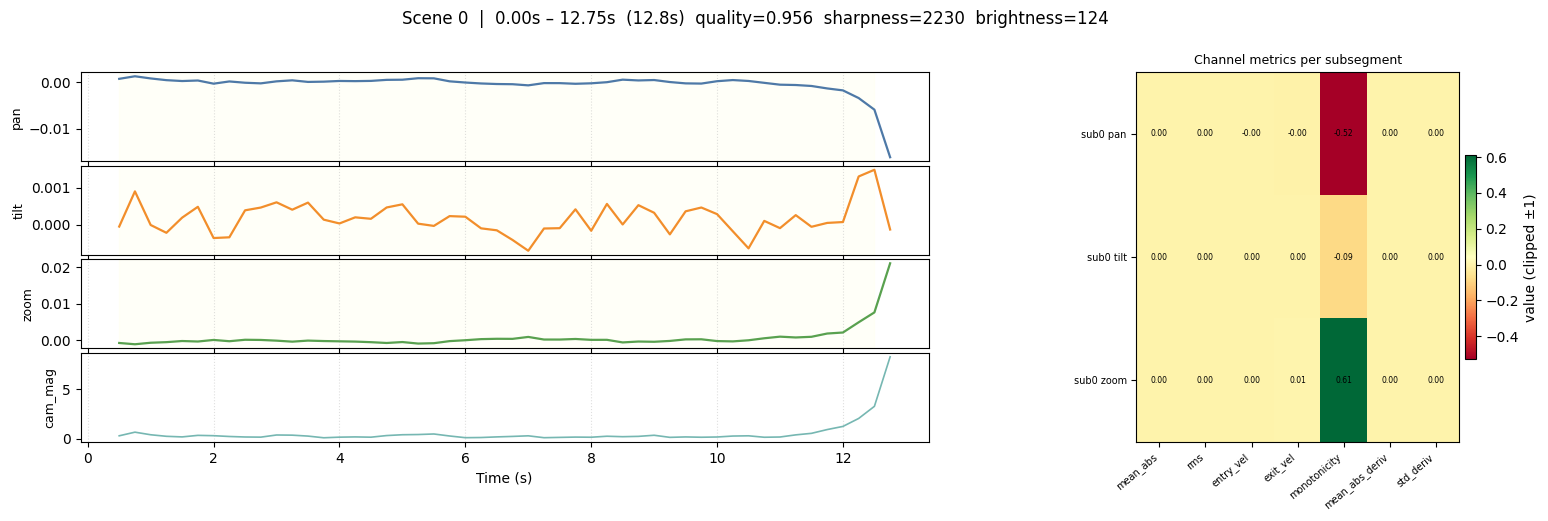

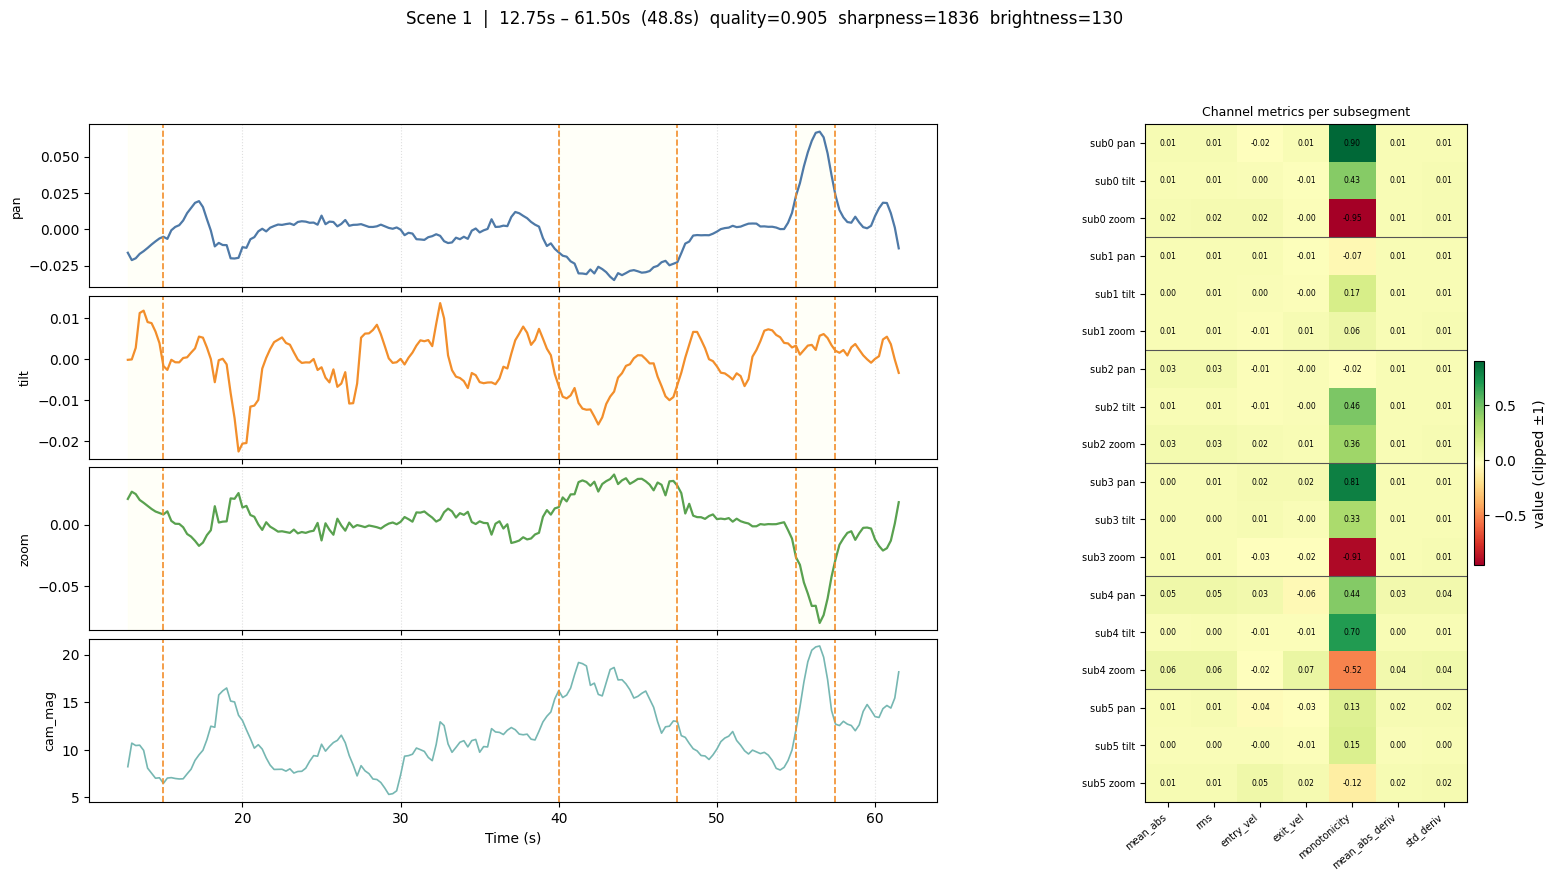

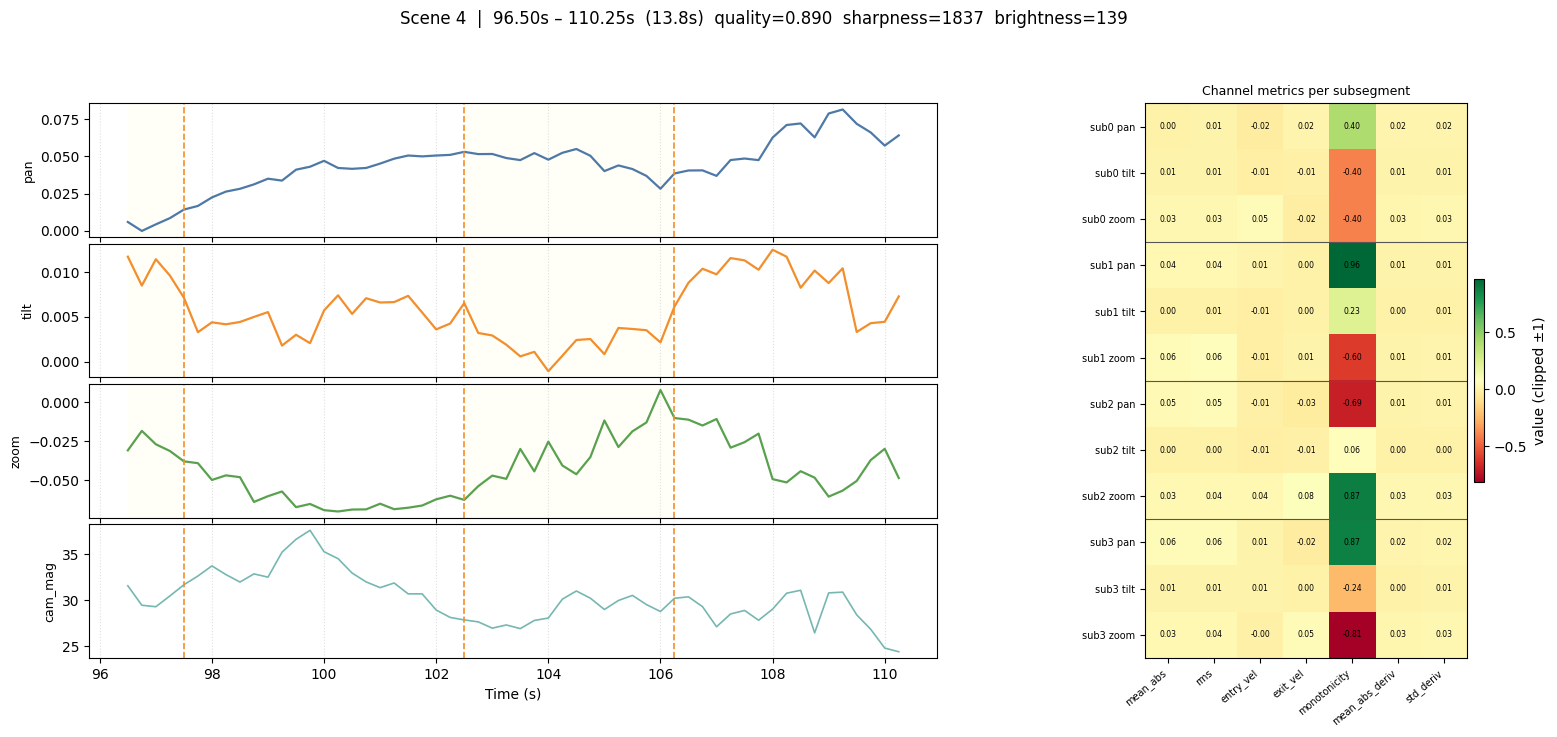

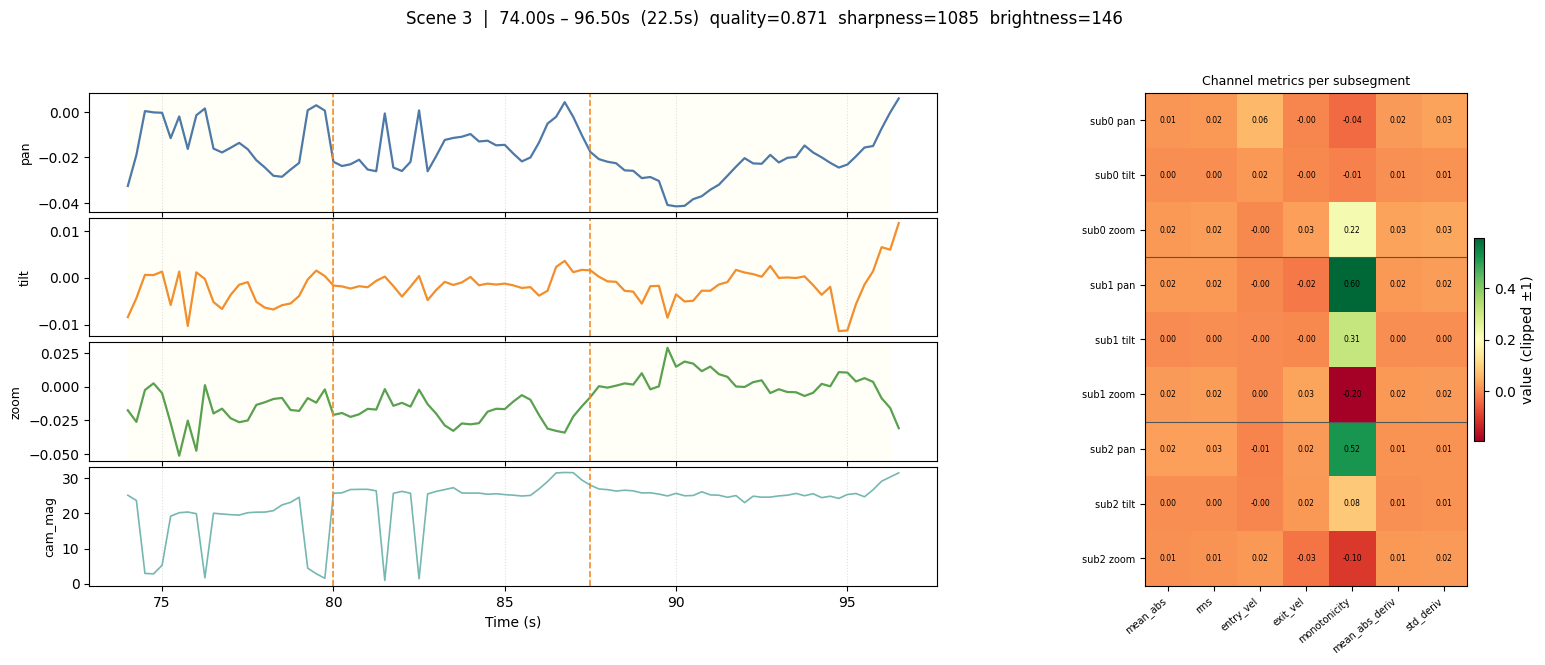

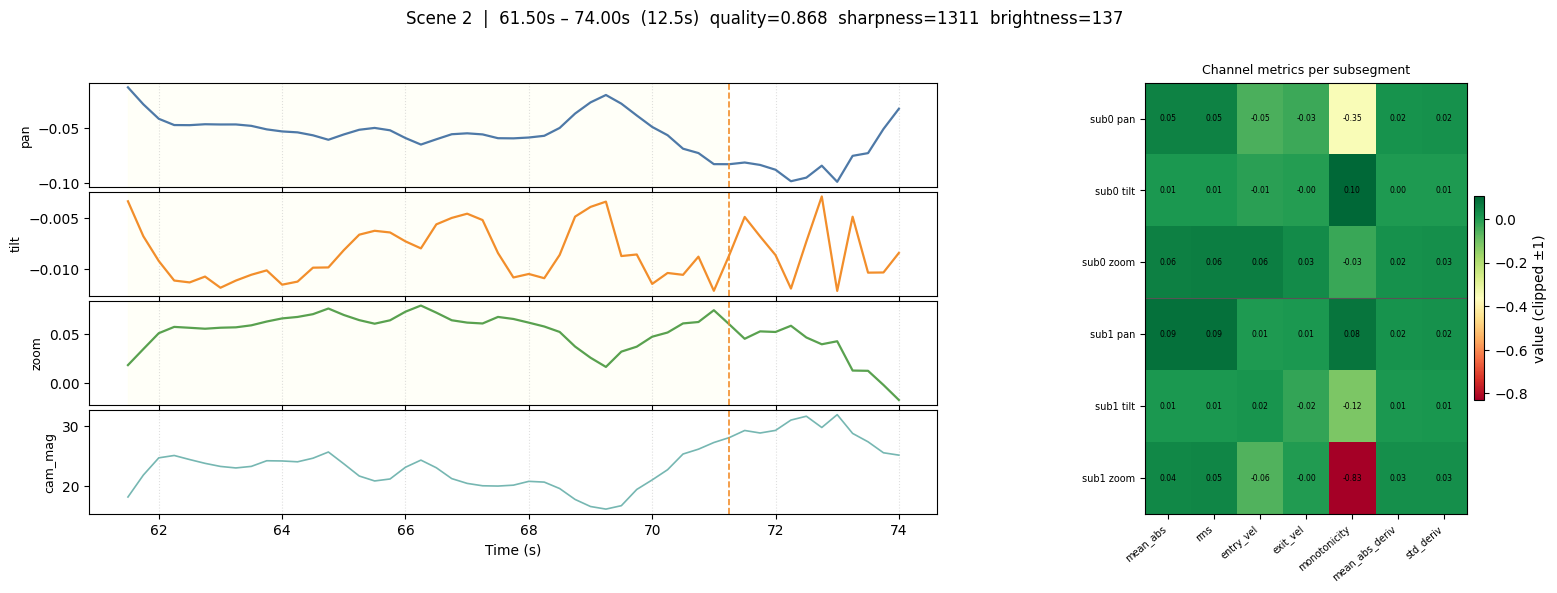

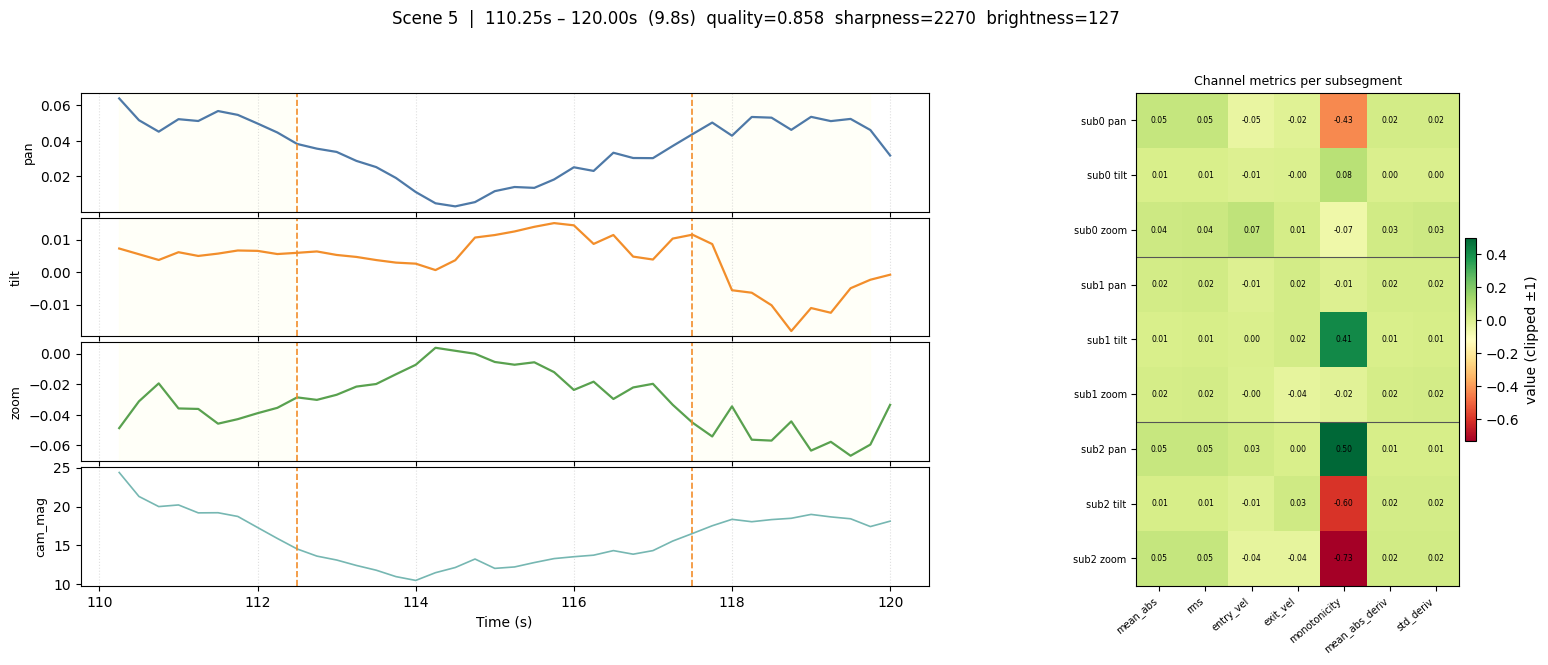

In [27]:
METRICS = ["mean_abs", "rms", "entry_vel", "exit_vel",
           "monotonicity", "mean_abs_deriv", "std_deriv"]

for scene in data["scenes"]:
    sid   = scene["scene_id"]
    t0, t1 = scene["start_time"], scene["end_time"]
    subs_s = scene["subsegments"]
    n_subs = len(subs_s)

    mask_fd = (fd["timestamp"] >= t0) & (fd["timestamp"] <= t1)

    fig = plt.figure(figsize=(18, 4 + n_subs * 0.8))
    fig.suptitle(
        f"Scene {sid}  |  {t0:.2f}s – {t1:.2f}s  ({scene['duration']:.1f}s)  "
        f"quality={scene['quality_score']:.3f}  "
        f"sharpness={scene['avg_sharpness']:.0f}  "
        f"brightness={scene['avg_brightness']:.0f}",
        fontsize=12, y=1.01,
    )

    gs = GridSpec(len(CHANNELS) + 1, 2, figure=fig,
                  width_ratios=[2.5, 1], hspace=0.05, wspace=0.35)

    # Left column: normalised fd channels for this scene
    ax_prev = None
    for row, ch in enumerate(CHANNELS):
        ax = fig.add_subplot(gs[row, 0], sharex=ax_prev)
        ax_prev = ax

        ax.plot(fd.loc[mask_fd, "timestamp"],
                fd.loc[mask_fd, ch],
                color=CHAN_COLORS[ch], lw=1.6, label=ch)

        # Subsegment boundaries
        for sub in subs_s[1:]:
            ax.axvline(sub["start_time"], color="#f28e2b", lw=1.2, ls="--")

        # Shade subsegments alternating
        for k, sub in enumerate(subs_s):
            ax.axvspan(sub["start_time"], sub["end_time"],
                       color="#ffe", alpha=0.4 if k % 2 == 0 else 0.0, zorder=0)

        ax.set_ylabel(ch, fontsize=9)
        ax.grid(axis="x", ls=":", alpha=0.4)
        if row < len(CHANNELS) - 1:
            plt.setp(ax.get_xticklabels(), visible=False)

    # Camera magnitude on last left row
    ax_cm = fig.add_subplot(gs[len(CHANNELS), 0], sharex=ax_prev)
    ax_cm.plot(fd.loc[mask_fd, "timestamp"],
               fd.loc[mask_fd, "camera_magnitude"],
               color="#76b7b2", lw=1.2, label="camera_magnitude")
    for sub in subs_s[1:]:
        ax_cm.axvline(sub["start_time"], color="#f28e2b", lw=1.2, ls="--")
    ax_cm.set_ylabel("cam_mag", fontsize=9)
    ax_cm.set_xlabel("Time (s)")
    ax_cm.grid(axis="x", ls=":", alpha=0.4)

    # Right column: per-subsegment metrics heatmap
    ax_heat = fig.add_subplot(gs[:, 1])
    if n_subs > 0:
        metric_mat = np.zeros((n_subs * len(CHANNELS), len(METRICS)))
        row_labels  = []
        for si, sub in enumerate(subs_s):
            for ci, ch in enumerate(CHANNELS):
                r = si * len(CHANNELS) + ci
                for mi, m in enumerate(METRICS):
                    metric_mat[r, mi] = sub["channel_metrics"][ch][m]
                row_labels.append(f"sub{si} {ch}")

        # Clip to [-1, 1] (monotonicity and velocities can be negative)
        im = ax_heat.imshow(metric_mat, aspect="auto",
                            cmap="RdYlGn", interpolation="nearest")
        ax_heat.set_xticks(range(len(METRICS)))
        ax_heat.set_xticklabels(METRICS, rotation=40, ha="right", fontsize=7)
        ax_heat.set_yticks(range(len(row_labels)))
        ax_heat.set_yticklabels(row_labels, fontsize=7)

        # Colour separators between subsegments
        for si in range(1, n_subs):
            ax_heat.axhline(si * len(CHANNELS) - 0.5, color="#555", lw=0.8)

        # Annotate values
        for r in range(metric_mat.shape[0]):
            for c in range(metric_mat.shape[1]):
                ax_heat.text(c, r, f"{metric_mat[r, c]:.2f}",
                             ha="center", va="center", fontsize=5.5,
                             color="black")

        plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02, label="value (clipped ±1)")
        ax_heat.set_title("Channel metrics per subsegment", fontsize=9)
    else:
        ax_heat.text(0.5, 0.5, "no subsegments", transform=ax_heat.transAxes,
                     ha="center", va="center", fontsize=11, color="#aaa")
        ax_heat.axis("off")

    plt.show()

## 6 · Entry & exit velocity vectors across all subsegments

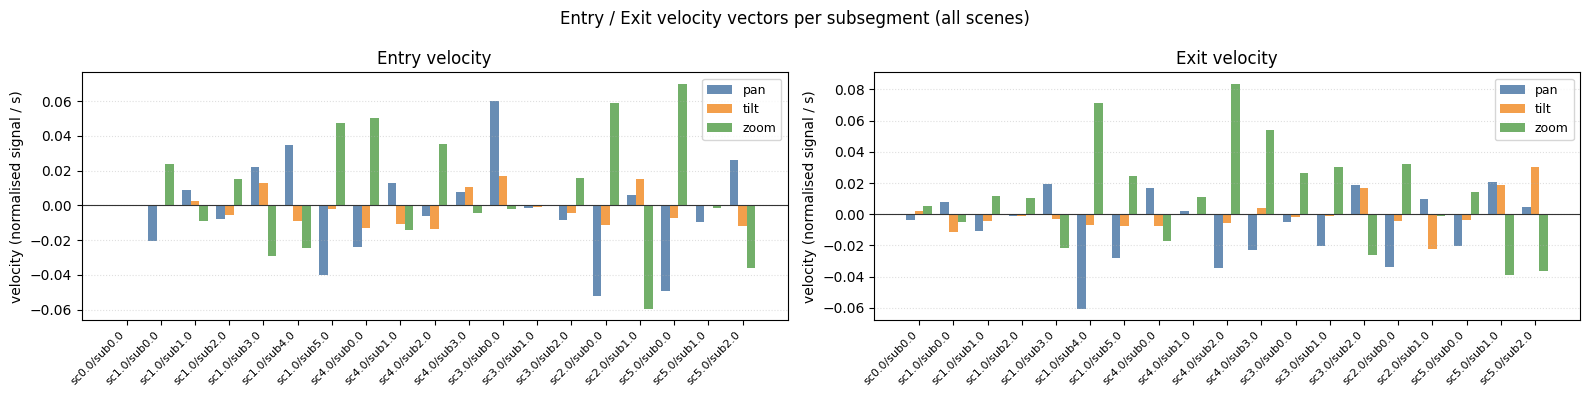

In [28]:
if len(subs) == 0:
    print("No subsegments found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)
    fig.suptitle("Entry / Exit velocity vectors per subsegment (all scenes)", fontsize=12)

    x = np.arange(len(subs))
    width = 0.25

    for ax, vel_key, title in zip(axes,
                                   ["entry_vel", "exit_vel"],
                                   ["Entry velocity", "Exit velocity"]):
        for i, ch in enumerate(CHANNELS):
            col = f"{ch}_{vel_key}"
            ax.bar(x + i * width, subs[col], width,
                   label=ch, color=CHAN_COLORS[ch], alpha=0.85)
        ax.axhline(0, color="#333", lw=0.8)
        ax.set_xticks(x + width)
        ax.set_xticklabels(
            [f"sc{r.scene_id}/sub{r.subsegment_id}" for _, r in subs.iterrows()],
            rotation=45, ha="right", fontsize=8,
        )
        ax.set_ylabel("velocity (normalised signal / s)")
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(axis="y", ls=":", alpha=0.4)

    plt.tight_layout()
    plt.show()

## 7 · Monotonicity & RMS per subsegment

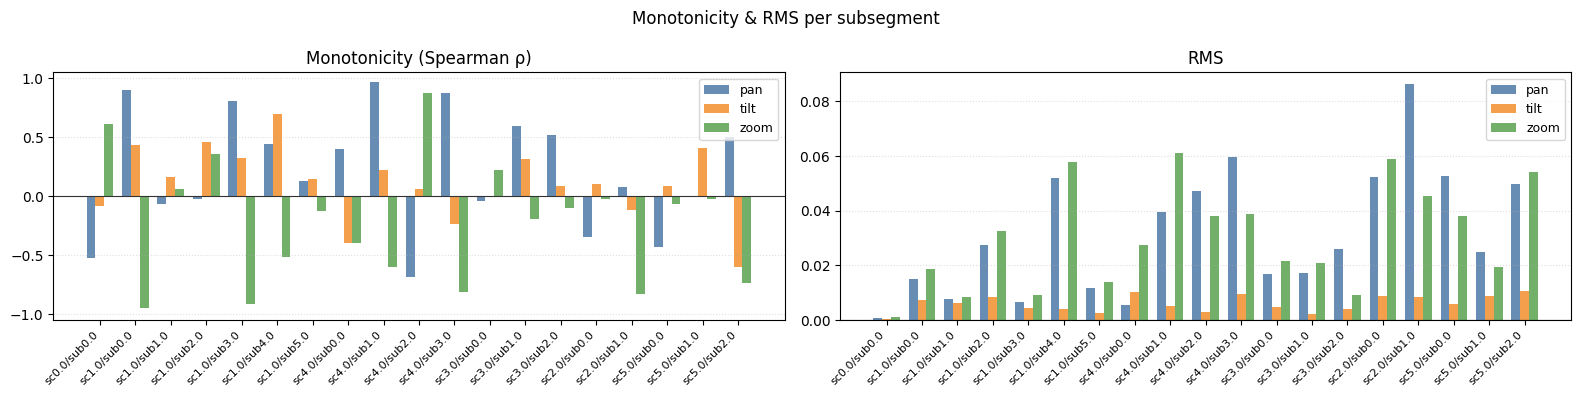

In [29]:
if len(subs) == 0:
    print("No subsegments found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle("Monotonicity & RMS per subsegment", fontsize=12)

    x = np.arange(len(subs))
    width = 0.25
    xlabels = [f"sc{r.scene_id}/sub{r.subsegment_id}" for _, r in subs.iterrows()]

    for ax, metric, title, ylim in [
        (axes[0], "monotonicity", "Monotonicity (Spearman ρ)", (-1.05, 1.05)),
        (axes[1], "rms",          "RMS",                       (0, None)),
    ]:
        for i, ch in enumerate(CHANNELS):
            ax.bar(x + i * width, subs[f"{ch}_{metric}"], width,
                   label=ch, color=CHAN_COLORS[ch], alpha=0.85)
        if ylim[0] is not None:
            ax.axhline(0, color="#333", lw=0.8)
        ax.set_xticks(x + width)
        ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(axis="y", ls=":", alpha=0.4)

    plt.tight_layout()
    plt.show()

## 8 · Subsegment summary table

In [30]:
if len(subs) == 0:
    print("No subsegments found.")
else:
    display_cols = (
        ["scene_id", "subsegment_id", "start_time", "end_time", "duration"]
        + [f"{ch}_{m}" for m in METRICS for ch in CHANNELS]
    )
    display_cols = [c for c in display_cols if c in subs.columns]

    styled = (
        subs[display_cols]
        .style
        .format(precision=3)
        .background_gradient(subset=[f"{ch}_monotonicity" for ch in CHANNELS],
                              cmap="RdYlGn", vmin=-1, vmax=1)
        .background_gradient(subset=[f"{ch}_rms" for ch in CHANNELS],
                              cmap="Blues", vmin=0, vmax=1)
        .background_gradient(subset=[f"{ch}_mean_abs_deriv" for ch in CHANNELS],
                              cmap="Oranges", vmin=0, vmax=0.5)
        .set_caption("Subsegment metrics (all scenes)")
    )
    display(styled)

,scene_id,subsegment_id,start_time,end_time,duration,pan_mean_abs,tilt_mean_abs,zoom_mean_abs,pan_rms,tilt_rms,zoom_rms,pan_entry_vel,tilt_entry_vel,zoom_entry_vel,pan_exit_vel,tilt_exit_vel,zoom_exit_vel,pan_monotonicity,tilt_monotonicity,zoom_monotonicity,pan_mean_abs_deriv,tilt_mean_abs_deriv,zoom_mean_abs_deriv,pan_std_deriv,tilt_std_deriv,zoom_std_deriv
0,0,0,0.500,12.500,12.000,0.000,0.000,0.001,0.001,0.000,0.001,-0.000,0.001,0.000,-0.004,0.002,0.005,-0.525,-0.086,0.609,0.001,0.001,0.001,0.001,0.001,0.002
1,1,0,12.750,15.000,2.250,0.014,0.006,0.018,0.015,0.007,0.019,-0.020,0.000,0.024,0.008,-0.011,-0.005,0.900,0.433,-0.950,0.010,0.009,0.011,0.010,0.011,0.012
2,1,1,15.000,40.000,25.000,0.006,0.005,0.006,0.008,0.006,0.008,0.009,0.003,-0.009,-0.011,-0.005,0.012,-0.068,0.166,0.059,0.007,0.007,0.010,0.010,0.010,0.014
3,1,2,40.000,47.500,7.500,0.027,0.007,0.032,0.027,0.009,0.033,-0.008,-0.005,0.015,-0.001,-0.001,0.010,-0.021,0.460,0.359,0.006,0.005,0.010,0.007,0.006,0.012
4,1,3,47.500,55.000,7.500,0.004,0.004,0.006,0.007,0.005,0.009,0.022,0.013,-0.029,0.019,-0.003,-0.022,0.806,0.325,-0.914,0.007,0.006,0.008,0.009,0.007,0.012
5,1,4,55.000,57.500,2.500,0.050,0.004,0.055,0.052,0.004,0.058,0.035,-0.009,-0.024,-0.061,-0.007,0.071,0.442,0.697,-0.515,0.034,0.005,0.039,0.037,0.005,0.042
6,1,5,57.500,61.250,3.750,0.010,0.002,0.012,0.012,0.003,0.014,-0.040,-0.002,0.048,-0.028,-0.007,0.025,0.132,0.146,-0.125,0.016,0.004,0.018,0.018,0.005,0.021
7,4,0,96.500,97.500,1.000,0.005,0.010,0.027,0.006,0.010,0.027,-0.024,-0.013,0.050,0.017,-0.007,-0.017,0.400,-0.400,-0.400,0.015,0.006,0.025,0.017,0.006,0.030
8,4,1,97.500,102.500,5.000,0.038,0.005,0.060,0.040,0.005,0.061,0.013,-0.010,-0.014,0.002,0.000,0.011,0.964,0.226,-0.600,0.009,0.004,0.011,0.007,0.005,0.013
9,4,2,102.500,106.250,3.750,0.047,0.002,0.034,0.047,0.003,0.038,-0.006,-0.013,0.035,-0.034,-0.005,0.084,-0.689,0.064,0.875,0.011,0.004,0.030,0.013,0.005,0.030
